<a href="https://colab.research.google.com/github/KarAnalytics/code_demos/blob/main/Video_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG with Video: Visual Question-Answering over Video Frames

This notebook demonstrates **Retrieval-Augmented Generation (RAG)** where the knowledge source is a **video**. Instead of searching documents or databases, we extract frames from a video, index them with CLIP embeddings, and retrieve the most relevant frames to answer natural-language questions.

**How it works:**
1. Generate a short **synthetic video** (animated product showcase — no external data needed).
2. Extract **keyframes** at regular intervals.
3. Compute **CLIP embeddings** for each frame to create a searchable index.
4. Given a natural-language question, retrieve the most relevant frame(s) via cosine similarity.
5. Send retrieved frames to a **multimodal LLM** for a grounded, natural-language answer.

**Learning goals:**
- Understand how RAG applies to temporal/video data
- See how frame extraction converts video into an image retrieval problem
- Practice grounding LLM output on visual evidence from specific moments in a video
- Compare answers with and without video context

**Provider setup:** This notebook supports **7 free-tier LLM APIs** with automatic fallback:
Gemini → Ollama → Grok (xAI) → Groq → HuggingFace → Cohere → OpenRouter.

Store whichever API keys you have in Colab Secrets (or a local `.env` file):
`GEMINI_API_KEY`, `OLLAMA_API_KEY`, `XAI_API_KEY`, `GROQ_API_KEY`, `HF_TOKEN`, `COHERE_API_KEY`, `OPENROUTER_API_KEY`

In [1]:
!pip install -q -U google-genai openai Pillow==11.0.0 transformers torch numpy matplotlib opencv-python-headless

## 1) Imports and Provider Helpers (7-Vendor Cascade)

We use **OpenCV** to create and read video, **CLIP** to embed frames and text queries into the same vector space, and **PIL/Pillow** for image display.

The provider helpers support **7 free-tier LLM APIs** with automatic fallback:
Gemini → Ollama → Grok (xAI) → Groq → HuggingFace → Cohere → OpenRouter.

Set whichever API keys you have in Colab Secrets or a `.env` file. On quota errors, the system automatically tries the next provider.

In [2]:
# =============================================================================
# Imports + LLM Provider Helpers — 7-Vendor Cascading Fallback
# =============================================================================
# Priority: Gemini → Ollama → Grok (xAI) → Groq → HuggingFace → Cohere → OpenRouter
#
# Store API keys in Colab Secrets or a local .env file:
#   GEMINI_API_KEY, OLLAMA_API_KEY, XAI_API_KEY, GROQ_API_KEY,
#   HF_TOKEN, COHERE_API_KEY, OPENROUTER_API_KEY
# =============================================================================

import os
import base64
import io
import math
import numpy as np
from pathlib import Path

import cv2
from PIL import Image, ImageDraw, ImageFont
from google import genai
from google.genai import types as genai_types
from openai import OpenAI

# ---- .env loader (for local VS Code / laptop testing) -----------------------
env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
if env_path.exists():
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value

# ---- Colab Secrets ----------------------------------------------------------
try:
    from google.colab import userdata  # type: ignore
except Exception:
    userdata = None


def _colab_secret(name):
    if userdata is None:
        return None
    try:
        return userdata.get(name)
    except Exception:
        return None


def _get_key(env_name):
    """Look up a key from env vars first, then Colab Secrets."""
    return os.getenv(env_name) or _colab_secret(env_name)


# ---- Provider definitions (in fallback order) --------------------------------
#
# | #  | Provider     | Free Tier                          | Signup URL                             |
# |----|--------------|------------------------------------|----------------------------------------|
# | 1  | Gemini       | 500 req/day (Flash)                | https://aistudio.google.com/apikey     |
# | 2  | Ollama Cloud | Free tier                          | https://ollama.com                     |
# | 3  | Grok (xAI)   | $25/month free credits             | https://console.x.ai                  |
# | 4  | Groq         | 30 req/min, 14400 req/day          | https://console.groq.com              |
# | 5  | HuggingFace  | Free serverless inference          | https://huggingface.co/settings/tokens |
# | 6  | Cohere       | 20 req/min free (trial key)        | https://dashboard.cohere.com/api-keys  |
# | 7  | OpenRouter   | Free models available (rotating)   | https://openrouter.ai/keys             |
#
PROVIDERS = [
    {
        "name": "Gemini",
        "key_env": "GEMINI_API_KEY",
        "style": "gemini",
        "default_model": "gemini-2.5-flash",
    },
    {
        "name": "Ollama",
        "key_env": "OLLAMA_API_KEY",
        "style": "openai",
        "base_url": "https://ollama.com/v1",
        "default_model": "kimi-k2.5:cloud",
    },
    {
        "name": "Grok (xAI)",
        "key_env": "XAI_API_KEY",
        "style": "openai",
        "base_url": "https://api.x.ai/v1",
        "default_model": "grok-3-mini",
    },
    {
        "name": "Groq",
        "key_env": "GROQ_API_KEY",
        "style": "openai",
        "base_url": "https://api.groq.com/openai/v1",
        "default_model": "llama-3.3-70b-versatile",
    },
    {
        "name": "HuggingFace",
        "key_env": "HF_TOKEN",
        "style": "openai",
        "base_url": "https://router.huggingface.co/v1",
        "default_model": "meta-llama/Llama-3.3-70B-Instruct",
    },
    {
        "name": "Cohere",
        "key_env": "COHERE_API_KEY",
        "style": "openai",
        "base_url": "https://api.cohere.ai/compatibility/v1",
        "default_model": "command-r-plus",
    },
    {
        "name": "OpenRouter",
        "key_env": "OPENROUTER_API_KEY",
        "style": "openai",
        "base_url": "https://openrouter.ai/api/v1",
        "default_model": "meta-llama/llama-3.3-70b-instruct:free",
    },
]


def _is_quota_error(exc):
    """Detect rate-limit / quota errors across providers."""
    msg = str(exc).lower()
    return any(s in msg for s in (
        "quota", "resource_exhausted", "429", "rate limit",
        "exceeded your current quota", "too many requests",
        "rate_limit_exceeded", "tokens per minute",
    ))


def get_available_providers():
    """Return the list of providers whose API keys are configured."""
    return [p for p in PROVIDERS if _get_key(p["key_env"])]


def has_llm_provider():
    """True if at least one provider is configured."""
    return len(get_available_providers()) > 0


def generate_text(prompt, system_prompt=None):
    """
    Send a text prompt through the provider cascade.
    Returns (response_text, provider_name).
    Tries each configured provider in order; skips on quota errors.
    """
    available = get_available_providers()
    if not available:
        raise ValueError(
            "No LLM provider configured. Set at least one API key:\n"
            + "\n".join(f"  {p['key_env']}" for p in PROVIDERS)
        )

    last_exc = None
    for provider in available:
        api_key = _get_key(provider["key_env"])
        try:
            if provider["style"] == "gemini":
                client = genai.Client(api_key=api_key)
                contents = prompt if not system_prompt else f"{system_prompt}\n\n{prompt}"
                resp = client.models.generate_content(
                    model=provider["default_model"], contents=contents,
                )
                return resp.text, provider["name"]
            else:
                client = OpenAI(api_key=api_key, base_url=provider["base_url"])
                messages = []
                if system_prompt:
                    messages.append({"role": "system", "content": system_prompt})
                messages.append({"role": "user", "content": prompt})
                resp = client.chat.completions.create(
                    model=provider["default_model"], messages=messages,
                )
                return resp.choices[0].message.content, provider["name"]

        except Exception as exc:
            last_exc = exc
            if _is_quota_error(exc):
                print(f"  [{provider['name']}] quota/rate-limit hit — trying next provider ...")
                continue
            else:
                raise

    raise RuntimeError(
        f"All providers exhausted (quota errors). Last error: {last_exc}"
    )


# ---- Print status -----------------------------------------------------------
available = get_available_providers()
if available:
    print("Providers configured (in fallback order):")
    for p in available:
        print(f"  + {p['name']:<16} model = {p['default_model']}")
    missing = [p for p in PROVIDERS if p not in available]
    if missing:
        print("Not configured (skipped):")
        for p in missing:
            print(f"  - {p['name']:<16} (set {p['key_env']})")
else:
    print("WARNING: No API keys found. Set at least one of:")
    for p in PROVIDERS:
        print(f"  {p['key_env']}")

Providers configured (in fallback order):
  + Gemini           model = gemini-2.5-flash
  + Ollama           model = kimi-k2.5:cloud
  + Groq             model = llama-3.3-70b-versatile
  + HuggingFace      model = meta-llama/Llama-3.3-70B-Instruct
  + Cohere           model = command-r-plus
  + OpenRouter       model = meta-llama/llama-3.3-70b-instruct:free
Not configured (skipped):
  - Grok (xAI)       (set XAI_API_KEY)


## 2) Generate a Synthetic Video

We create a short animated video that simulates a **product showcase reel**. The video has distinct scenes, each showing a different product with visual attributes that change over time.

This keeps the demo self-contained (no external video files needed) while providing enough visual variety to test retrieval.

| Time (sec) | Scene | Content |
|---|---|---|
| 0–3 | Title card | "Acme Corp Product Showcase" on blue background |
| 3–7 | Product 1 | Red circle — "Widget Alpha" with price |
| 7–11 | Product 2 | Green triangle — "Gadget Beta" with price |
| 11–15 | Product 3 | Blue square — "Tool Gamma" with price |
| 15–19 | Product 4 | Orange diamond — "Device Delta" with price |
| 19–22 | Closing card | "Thank you! Visit acme-corp.example.com" |

In [3]:
VIDEO_PATH = "product_showcase.mp4"
FPS = 10
WIDTH, HEIGHT = 640, 480

# Scene definitions
SCENES = [
    {
        "name": "title",
        "start": 0, "end": 3,
        "label": "Acme Corp\nProduct Showcase 2026",
        "bg_color": (40, 60, 120),
        "shape": None,
        "product": None,
    },
    {
        "name": "widget_alpha",
        "start": 3, "end": 7,
        "label": "Widget Alpha — $12.99",
        "bg_color": (255, 245, 238),
        "shape": "circle",
        "shape_color": (231, 76, 60),
        "product": {"name": "Widget Alpha", "price": 12.99, "color": "red", "shape": "circle"},
    },
    {
        "name": "gadget_beta",
        "start": 7, "end": 11,
        "label": "Gadget Beta — $8.75",
        "bg_color": (240, 255, 240),
        "shape": "triangle",
        "shape_color": (46, 204, 113),
        "product": {"name": "Gadget Beta", "price": 8.75, "color": "green", "shape": "triangle"},
    },
    {
        "name": "tool_gamma",
        "start": 11, "end": 15,
        "label": "Tool Gamma — $34.99",
        "bg_color": (235, 245, 255),
        "shape": "square",
        "shape_color": (52, 152, 219),
        "product": {"name": "Tool Gamma", "price": 34.99, "color": "blue", "shape": "square"},
    },
    {
        "name": "device_delta",
        "start": 15, "end": 19,
        "label": "Device Delta — $19.25",
        "bg_color": (255, 248, 230),
        "shape": "diamond",
        "shape_color": (230, 126, 34),
        "product": {"name": "Device Delta", "price": 19.25, "color": "orange", "shape": "diamond"},
    },
    {
        "name": "closing",
        "start": 19, "end": 22,
        "label": "Thank you!\nVisit acme-corp.example.com",
        "bg_color": (40, 60, 120),
        "shape": None,
        "product": None,
    },
]


def draw_frame_pil(scene, t, width=WIDTH, height=HEIGHT):
    """Draw a single video frame for a given scene and time offset using PIL."""
    bg = scene["bg_color"]
    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)

    # Load font
    try:
        font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
    except (OSError, IOError):
        try:
            font_large = ImageFont.truetype("arial.ttf", 28)
            font_small = ImageFont.truetype("arial.ttf", 22)
        except (OSError, IOError):
            font_large = ImageFont.load_default()
            font_small = font_large

    cx, cy = width // 2, height // 2

    if scene["shape"] is None:
        # Title or closing card — centered text
        text_color = (255, 255, 255)
        lines = scene["label"].split("\n")
        total_h = len(lines) * 40
        y_start = cy - total_h // 2
        for j, line in enumerate(lines):
            bbox = draw.textbbox((0, 0), line, font=font_large)
            tw = bbox[2] - bbox[0]
            draw.text(((width - tw) // 2, y_start + j * 40), line, fill=text_color, font=font_large)
    else:
        # Product scene — animated shape (gentle bounce)
        bounce = int(15 * math.sin(t * 3))
        shape_cy = cy - 30 + bounce
        r = 80
        color = scene["shape_color"]

        if scene["shape"] == "circle":
            draw.ellipse([cx - r, shape_cy - r, cx + r, shape_cy + r], fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "square":
            draw.rectangle([cx - r, shape_cy - r, cx + r, shape_cy + r], fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "triangle":
            pts = [(cx, shape_cy - r), (cx - r, shape_cy + r), (cx + r, shape_cy + r)]
            draw.polygon(pts, fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "diamond":
            pts = [(cx, shape_cy - r), (cx + r, shape_cy), (cx, shape_cy + r), (cx - r, shape_cy)]
            draw.polygon(pts, fill=color, outline=(0, 0, 0), width=3)

        # Product label at top
        bbox = draw.textbbox((0, 0), scene["label"], font=font_small)
        tw = bbox[2] - bbox[0]
        draw.text(((width - tw) // 2, 20), scene["label"], fill=(30, 30, 30), font=font_small)

        # Timestamp at bottom-right
        ts_text = f"t={t:.1f}s"
        draw.text((width - 90, height - 30), ts_text, fill=(120, 120, 120), font=font_small)

    return img


def generate_video(path, scenes, fps, width=WIDTH, height=HEIGHT):
    """Generate an MP4 video from scene definitions."""
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(path, fourcc, fps, (width, height))

    for scene in scenes:
        duration = scene["end"] - scene["start"]
        n_frames = int(duration * fps)
        for i in range(n_frames):
            t = scene["start"] + i / fps
            pil_img = draw_frame_pil(scene, t, width, height)
            # Convert PIL (RGB) -> OpenCV (BGR)
            frame = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
            writer.write(frame)

    writer.release()


generate_video(VIDEO_PATH, SCENES, FPS)
total_duration = SCENES[-1]["end"]
file_size_kb = Path(VIDEO_PATH).stat().st_size / 1024
print(f"Video generated: '{VIDEO_PATH}'")
print(f"  Duration: {total_duration}s | FPS: {FPS} | Resolution: {WIDTH}x{HEIGHT} | Size: {file_size_kb:.0f} KB")

Video generated: 'product_showcase.mp4'
  Duration: 22s | FPS: 10 | Resolution: 640x480 | Size: 260 KB


## 3) Extract Keyframes from the Video

Video RAG works by converting the temporal video data into a set of **keyframes** — representative images sampled at regular intervals.

We extract one frame per second, which is enough to capture each scene in our showcase video. For longer or faster-paced videos you would adjust the sampling rate.

In [13]:
def extract_keyframes(video_path, interval_sec=1.0):
    """Extract frames from a video at a fixed time interval.

    Returns a list of dicts: {"timestamp": float, "image": PIL.Image}
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    frame_interval = int(fps * interval_sec)

    frames = []
    frame_idx = 0
    while True:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR -> RGB -> PIL
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)
        timestamp = frame_idx / fps
        frames.append({"timestamp": timestamp, "image": pil_img})
        frame_idx += frame_interval

    cap.release()
    return frames, duration


keyframes, video_duration = extract_keyframes(VIDEO_PATH, interval_sec=1.0)
print(f"Extracted {len(keyframes)} keyframes from {video_duration:.1f}s video (1 frame/sec)")
print(f"Timestamps: {[f'{kf["timestamp"]:.1f}s' for kf in keyframes]}")

Extracted 22 keyframes from 22.0s video (1 frame/sec)
Timestamps: ['0.0s', '1.0s', '2.0s', '3.0s', '4.0s', '5.0s', '6.0s', '7.0s', '8.0s', '9.0s', '10.0s', '11.0s', '12.0s', '13.0s', '14.0s', '15.0s', '16.0s', '17.0s', '18.0s', '19.0s', '20.0s', '21.0s']


### Preview Keyframes

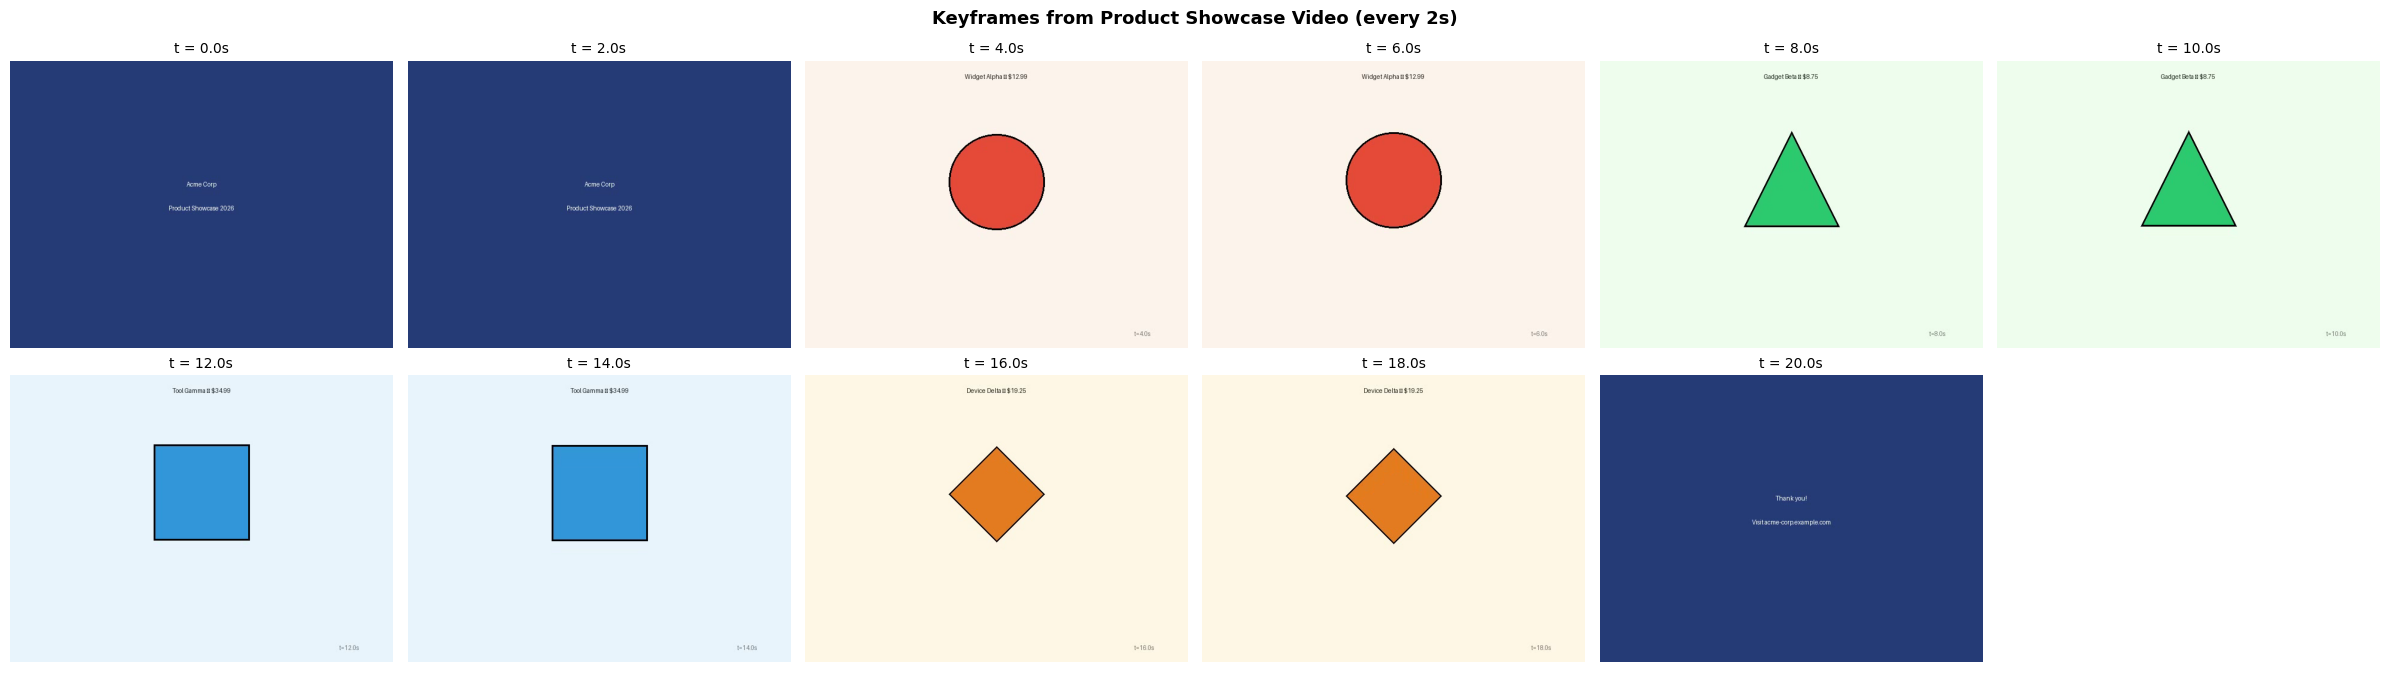

In [5]:
import matplotlib.pyplot as plt

# Show a subset of keyframes (every other frame to save space)
display_frames = keyframes[::2]
n = len(display_frames)
cols = min(n, 6)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]
for i, ax in enumerate(axes_flat):
    if i < n:
        ax.imshow(display_frames[i]["image"])
        ax.set_title(f"t = {display_frames[i]['timestamp']:.1f}s", fontsize=10)
    ax.axis("off")
fig.suptitle("Keyframes from Product Showcase Video (every 2s)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4) Build the Frame Index with CLIP Embeddings

Just like in Image RAG, we use **CLIP** to embed each keyframe into a vector. At query time we embed the user's text and find the closest frame(s).

The key difference from Image RAG: each frame also carries a **timestamp**, so we can tell the user *when* in the video the relevant content appears.

In [6]:
from transformers import CLIPProcessor, CLIPModel
import torch

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

print(f"CLIP model loaded: {CLIP_MODEL_NAME}")
print(f"Embedding dimension: {clip_model.config.projection_dim}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32
Embedding dimension: 512


In [7]:
def embed_frames(keyframes, model, processor):
    """Compute CLIP embeddings for a list of keyframe images."""
    images = [kf["image"].convert("RGB") for kf in keyframes]
    inputs = processor(images=images, return_tensors="pt", padding=True)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs).pooler_output
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


def embed_text(query, model, processor):
    """Compute CLIP embedding for a text query."""
    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        embeddings = model.get_text_features(**inputs).pooler_output
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


# Build the frame index
frame_embeddings = embed_frames(keyframes, clip_model, clip_processor)
print(f"Frame index built: {frame_embeddings.shape[0]} frames, {frame_embeddings.shape[1]}-dim embeddings")

Frame index built: 22 frames, 512-dim embeddings


## 5) Frame Retrieval — the "Retrieval" in Video RAG

Given a text query, we:
1. Embed the query with CLIP's text encoder.
2. Compute **cosine similarity** against all frame embeddings.
3. Return the top-k most similar frames with their timestamps.

The timestamp tells us *when* in the video the answer can be found.

Query: 'red circle product'

  #1 t=4.0s | widget_alpha | Widget Alpha (red circle) | sim=0.2703
  #2 t=6.0s | widget_alpha | Widget Alpha (red circle) | sim=0.2668
  #3 t=5.0s | widget_alpha | Widget Alpha (red circle) | sim=0.2657


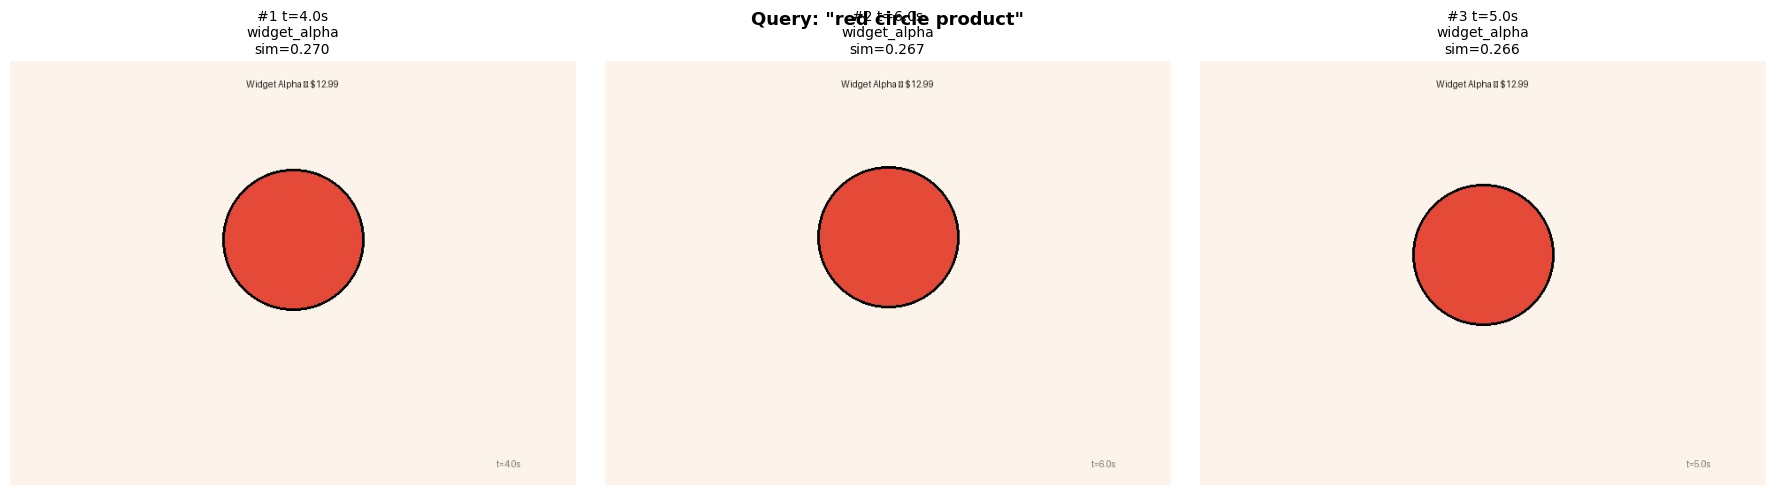

In [8]:
def get_scene_for_timestamp(timestamp, scenes):
    """Look up which scene a timestamp belongs to."""
    for scene in scenes:
        if scene["start"] <= timestamp < scene["end"]:
            return scene
    return scenes[-1]  # default to last scene


def retrieve_frames(query, frame_embeddings, keyframes, model, processor, top_k=3):
    """Retrieve the top-k most relevant video frames for a text query."""
    query_emb = embed_text(query, model, processor)
    similarities = (query_emb @ frame_embeddings.T).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        ts = keyframes[idx]["timestamp"]
        scene = get_scene_for_timestamp(ts, SCENES)
        results.append({
            "rank": len(results) + 1,
            "frame_index": int(idx),
            "timestamp": ts,
            "scene_name": scene["name"],
            "product": scene.get("product"),
            "image": keyframes[idx]["image"],
            "similarity": float(similarities[idx]),
        })
    return results


def show_retrieved_frames(query, results):
    """Display retrieved frames side by side."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        ax.imshow(r["image"])
        label = f"#{r['rank']} t={r['timestamp']:.1f}s\n{r['scene_name']}\nsim={r['similarity']:.3f}"
        ax.set_title(label, fontsize=10)
        ax.axis("off")
    fig.suptitle(f'Query: "{query}"', fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Test retrieval
test_query = "red circle product"
results = retrieve_frames(test_query, frame_embeddings, keyframes, clip_model, clip_processor)

print(f"Query: '{test_query}'\n")
for r in results:
    prod = r['product']
    prod_str = f"{prod['name']} ({prod['color']} {prod['shape']})" if prod else "(no product)"
    print(f"  #{r['rank']} t={r['timestamp']:.1f}s | {r['scene_name']} | {prod_str} | sim={r['similarity']:.4f}")

show_retrieved_frames(test_query, results)

## 6) Answer Generation — Multimodal LLM with Retrieved Frames

The multimodal LLM receives:
- The **retrieved frames** (as images)
- **Metadata** about each frame (timestamp, scene, product info)
- The user's **question**

It generates an answer grounded on what it can see in the frames and the associated timestamps.

We also provide a "without RAG" function that answers with no video context.

In [9]:
def build_frame_context(results):
    """Build a text description of retrieved frames."""
    lines = ["Retrieved video frames (ranked by visual similarity):"]
    for r in results:
        prod = r["product"]
        prod_str = (
            f"{prod['name']}: {prod['color']} {prod['shape']}, ${prod['price']:.2f}"
            if prod else "(title/closing card)"
        )
        lines.append(
            f"  #{r['rank']} timestamp={r['timestamp']:.1f}s, scene={r['scene_name']}, "
            f"product={prod_str}, similarity={r['similarity']:.3f}"
        )
    return "\n".join(lines)


VIDEO_RAG_SYSTEM_PROMPT = (
    "You are a helpful video analyst. You are given keyframes extracted from a product "
    "showcase video, along with their timestamps and metadata. Answer the user's question "
    "based on what you can SEE in the frames and the provided metadata. Reference specific "
    "timestamps when relevant (e.g., 'at t=5.0s'). If the frames do not contain enough "
    "information, say so. Do not invent products or details not shown."
)


def generate_answer_with_frames(question, results):
    """Send retrieved frames + metadata to a multimodal LLM via the 7-vendor cascade.

    Gemini gets native multimodal (images + text).
    All other providers get text-only with metadata context.
    """
    context_text = build_frame_context(results)
    available = get_available_providers()
    if not available:
        raise ValueError(
            "No LLM provider configured. Set at least one API key:\n"
            + "\n".join(f"  {p['key_env']}" for p in PROVIDERS)
        )

    last_exc = None
    for provider in available:
        api_key = _get_key(provider["key_env"])
        try:
            if provider["style"] == "gemini":
                # Gemini: native multimodal — send actual images
                client = genai.Client(api_key=api_key)
                parts = []
                parts.append(genai_types.Part.from_text(
                    text=f"{VIDEO_RAG_SYSTEM_PROMPT}\n\n{context_text}\n\nQUESTION: {question}"
                ))
                for r in results:
                    buf = io.BytesIO()
                    r["image"].save(buf, format="PNG")
                    parts.append(genai_types.Part.from_bytes(data=buf.getvalue(), mime_type="image/png"))
                resp = client.models.generate_content(model=provider["default_model"], contents=parts)
                return resp.text, provider["name"]
            else:
                # OpenAI-compatible: text-only with metadata
                client = OpenAI(api_key=api_key, base_url=provider["base_url"])
                messages = [
                    {"role": "system", "content": VIDEO_RAG_SYSTEM_PROMPT},
                    {"role": "user", "content": f"{context_text}\n\nQUESTION: {question}"},
                ]
                resp = client.chat.completions.create(model=provider["default_model"], messages=messages)
                return resp.choices[0].message.content, provider["name"]

        except Exception as exc:
            last_exc = exc
            if _is_quota_error(exc):
                print(f"  [{provider['name']}] quota/rate-limit hit — trying next provider ...")
                continue
            else:
                raise

    raise RuntimeError(f"All providers exhausted (quota errors). Last error: {last_exc}")


def generate_answer_without_rag(question):
    """Direct LLM answer with NO video frames — uses the 7-vendor cascade."""
    return generate_text(question)


print("Answer generation functions ready (7-vendor cascade).")

Answer generation functions ready (7-vendor cascade).


## 7) Full Video RAG Pipeline

In [10]:
def answer_with_video_rag(question, top_k=3):
    """Full Video RAG: extract frames -> CLIP retrieval -> multimodal LLM answer."""
    print(f"  [Step 1] Embedding query with CLIP ...")
    results = retrieve_frames(
        question, frame_embeddings, keyframes, clip_model, clip_processor, top_k=top_k,
    )
    print(f"  [Step 2] Retrieved {len(results)} frame(s):")
    for r in results:
        prod_name = r['product']['name'] if r['product'] else '(card)'
        print(f"           #{r['rank']} t={r['timestamp']:.1f}s — {prod_name} (sim={r['similarity']:.3f})")

    print(f"  [Step 3] Generating multimodal answer ...")
    answer, provider = generate_answer_with_frames(question, results)
    print(f"  [Step 4] Answer generated (provider: {provider})")
    return answer, results, provider


print("Video RAG pipeline ready.")

Video RAG pipeline ready.


## 8) Run End-to-End Examples: With RAG vs. Without RAG

We test questions about the product showcase video and compare:
- **With Video RAG:** CLIP retrieves the relevant frame(s), multimodal LLM answers with visual + temporal grounding
- **Without RAG:** LLM answers with no video context — it knows nothing about our product showcase

Watch how the without-RAG answers either refuse to answer (no context) or hallucinate product details.


Q1. What is the red product shown in the video and how much does it cost?

--- WITH VIDEO RAG ---
  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 3 frame(s):
           #1 t=6.0s — Widget Alpha (sim=0.255)
           #2 t=4.0s — Widget Alpha (sim=0.251)
           #3 t=5.0s — Widget Alpha (sim=0.250)
  [Step 3] Generating multimodal answer ...
  [Step 4] Answer generated (provider: Gemini)


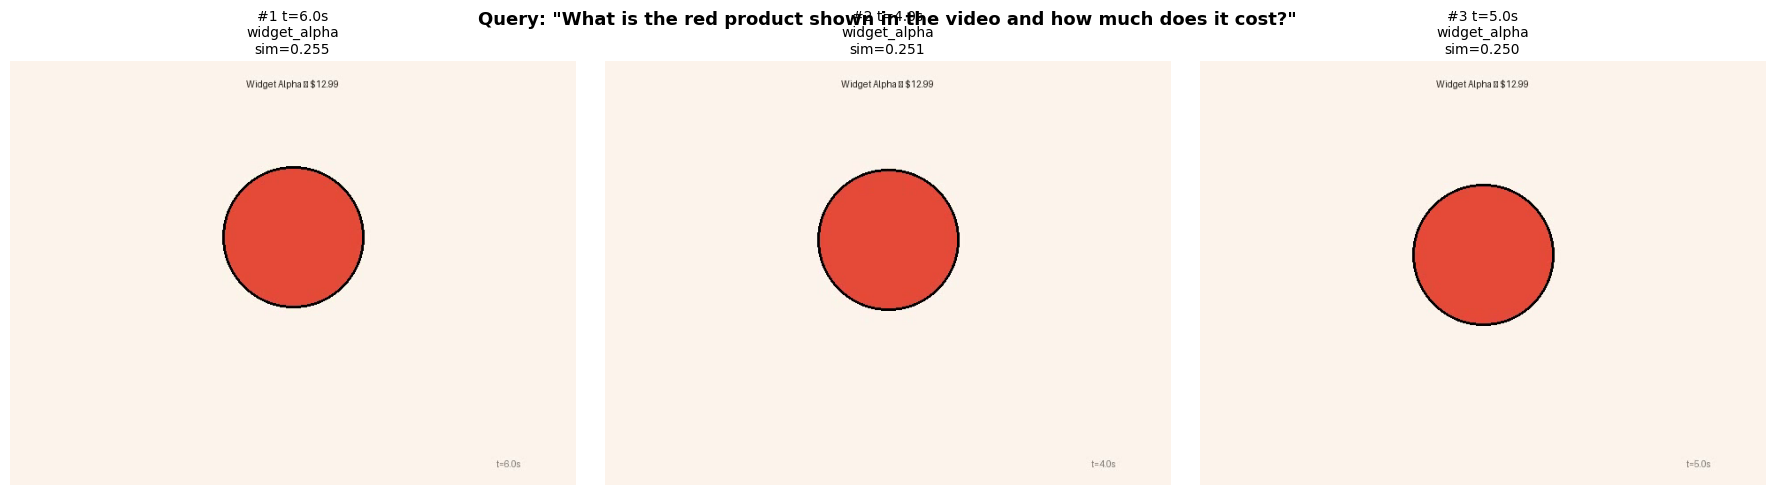


  Answer (provider: Gemini):
The red product shown in the video is **Widget Alpha**, as seen in all provided frames (e.g., at t=6.0s, t=4.0s, t=5.0s). It costs **$12.99**.

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] quota/rate-limit hit — trying next provider ...
  Answer (provider: Ollama):
I don't see any video attached to your message, so I'm unable to identify the red product you're referring to or provide pricing information.

To help you, could you please:

1. **Describe the product** - What does it look like? (shape, size, any text/logos visible)
2. **Describe the video** - Where did you see it? (TikTok, Instagram, YouTube, etc.) What was happening in the clip?
3. **Share a screenshot** - You can upload an image of the product here
4. **Provide context** - What category might it be? (Beauty tool, kitchen gadget, electronics, clothing item, etc.)

Once you provide some details, I'll do my best to identify it and find current pricing information for you!


Q2. At what po

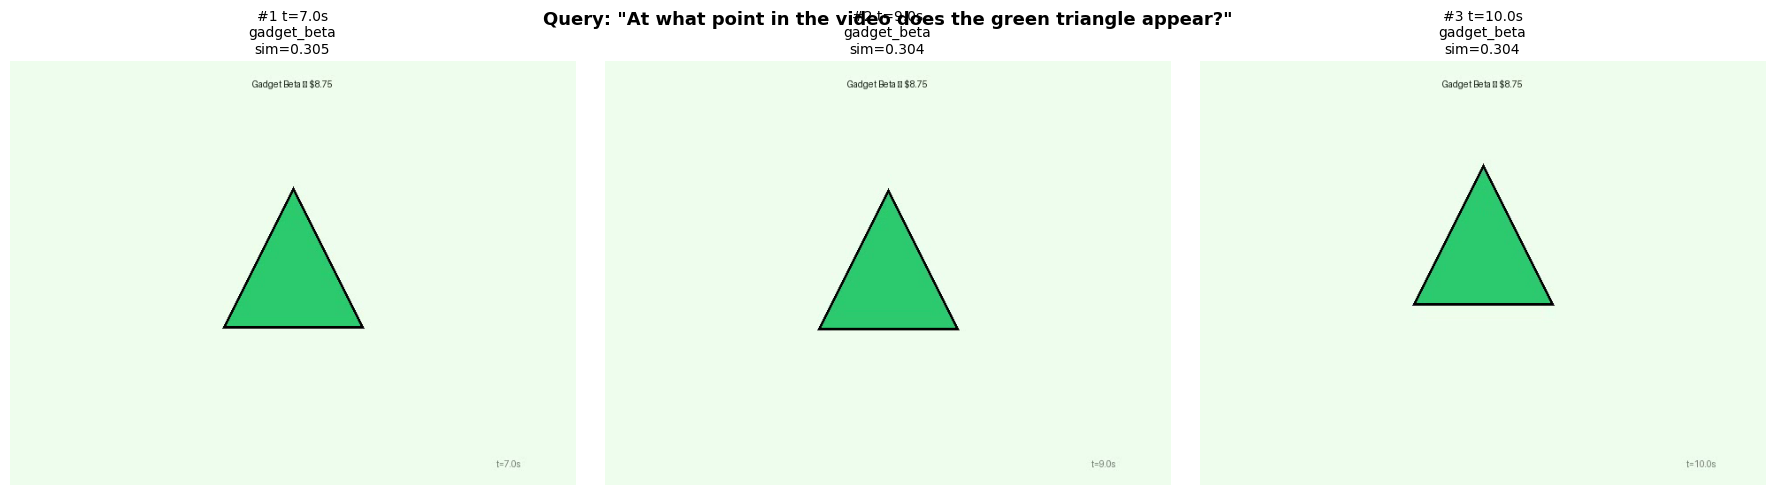


  Answer (provider: Gemini):
Based on the provided keyframes, the green triangle appears at t=7.0s. It is also visible in the subsequent frames at t=9.0s and t=10.0s.

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] quota/rate-limit hit — trying next provider ...
  Answer (provider: Ollama):
I don't have access to the video you're referring to. Could you please provide more details, such as:

- The **title** of the video or a **link** to it
- A **description** of what happens** in the video
- **Context** about what the video is (e.g., a tutorial, a specific YouTube video, a film, etc.)

If you can describe the scene or provide a transcript/timestamp details, I'd be happy to help you identify when the green triangle appears!


Q3. What is the most expensive product in this showcase video?

--- WITH VIDEO RAG ---
  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 3 frame(s):
           #1 t=5.0s — Widget Alpha (sim=0.215)
           #2 t=6.0s — Widget Alpha (sim=0.214)
  

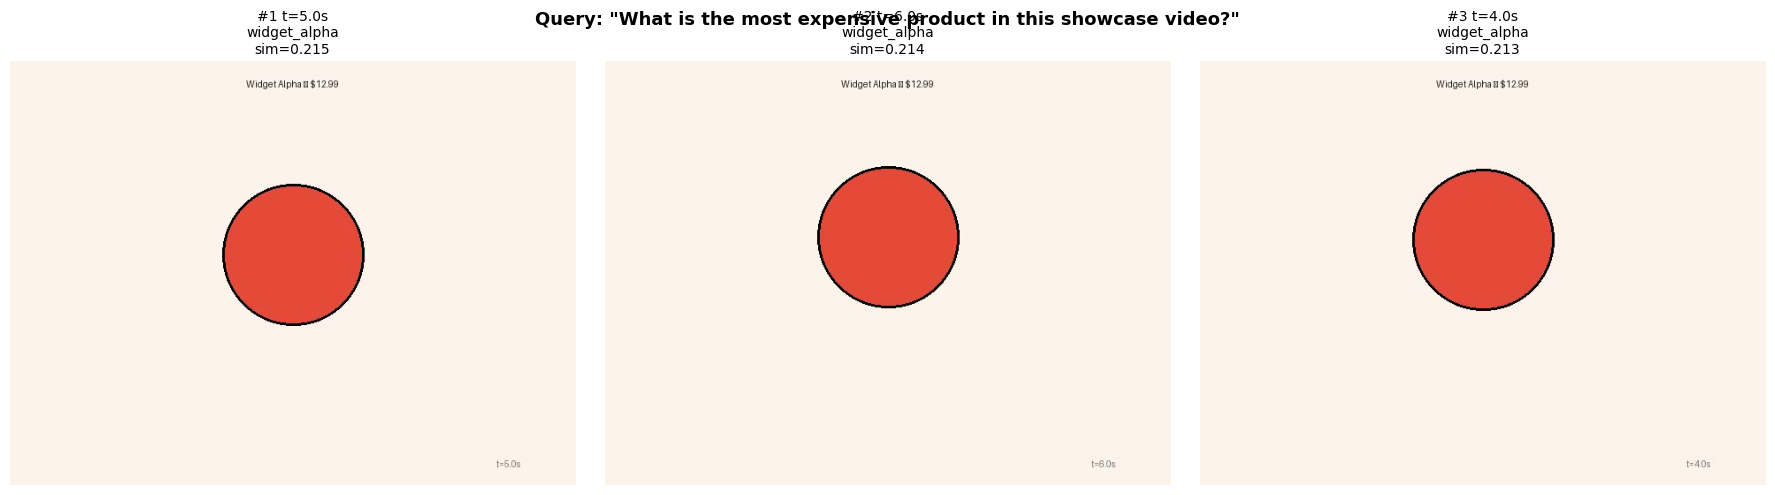


  Answer (provider: Ollama):
Based on the provided frames, I can only see **Widget Alpha** (a red circle) priced at **$12.99** at timestamps 4.0s, 5.0s, and 6.0s. 

Since these frames only show one product and do not display any other products or their prices, **I cannot determine which is the most expensive product in the showcase video**. The frames do not contain enough information to make a price comparison.

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] quota/rate-limit hit — trying next provider ...
  Answer (provider: Ollama):
I don't see a video link or description attached to your message. I don't have the ability to view or access external videos, including YouTube links, TikToks, or video files you might be watching.

To help you identify the most expensive product, could you please:

1. **Describe the video** (title, creator, or what products are shown)
2. **List the products** shown in the showcase
3. **Provide a link** to the video, and I can help analyze the conte

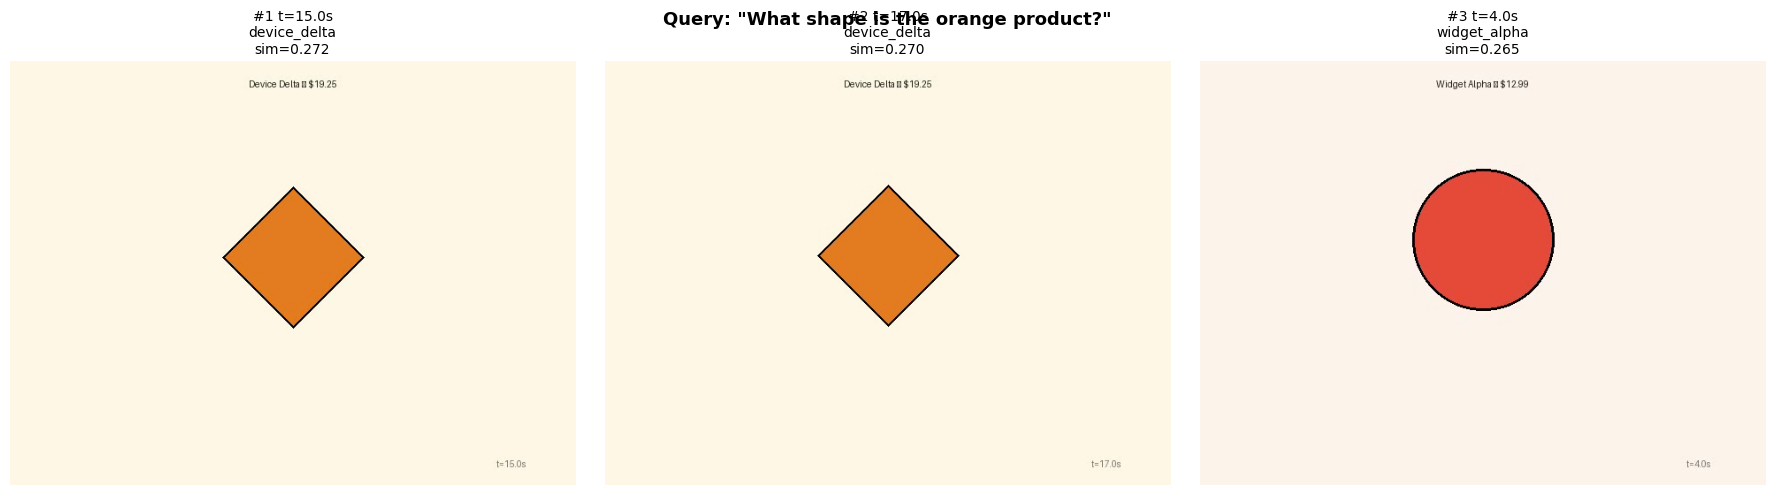


  Answer (provider: Gemini):
Based on the provided frames and metadata:

The orange product, identified as "Device Delta," is a **diamond** shape. This is visible in frames at t=15.0s and t=17.0s. The metadata for these frames also describes it as an "orange diamond."

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] quota/rate-limit hit — trying next provider ...
  Answer (provider: Ollama):
I don't have enough context to answer your question definitively. "The orange product" could refer to several things depending on what you're looking at:

**If you're referring to an image or diagram:**
- Please describe what you see or share the image, as I cannot see visual content you're viewing

**If you mean a physical product:**
- **Traffic cone**: Cone-shaped
- **Basketball**: Spherical
- **Orange (fruit)**: Spherical or slightly oblate
- **Carrot**: Conical/cylindrical

**If this is a chemistry question:**
- Many orange-colored compounds exist (like potassium dichromate or hydrated iro

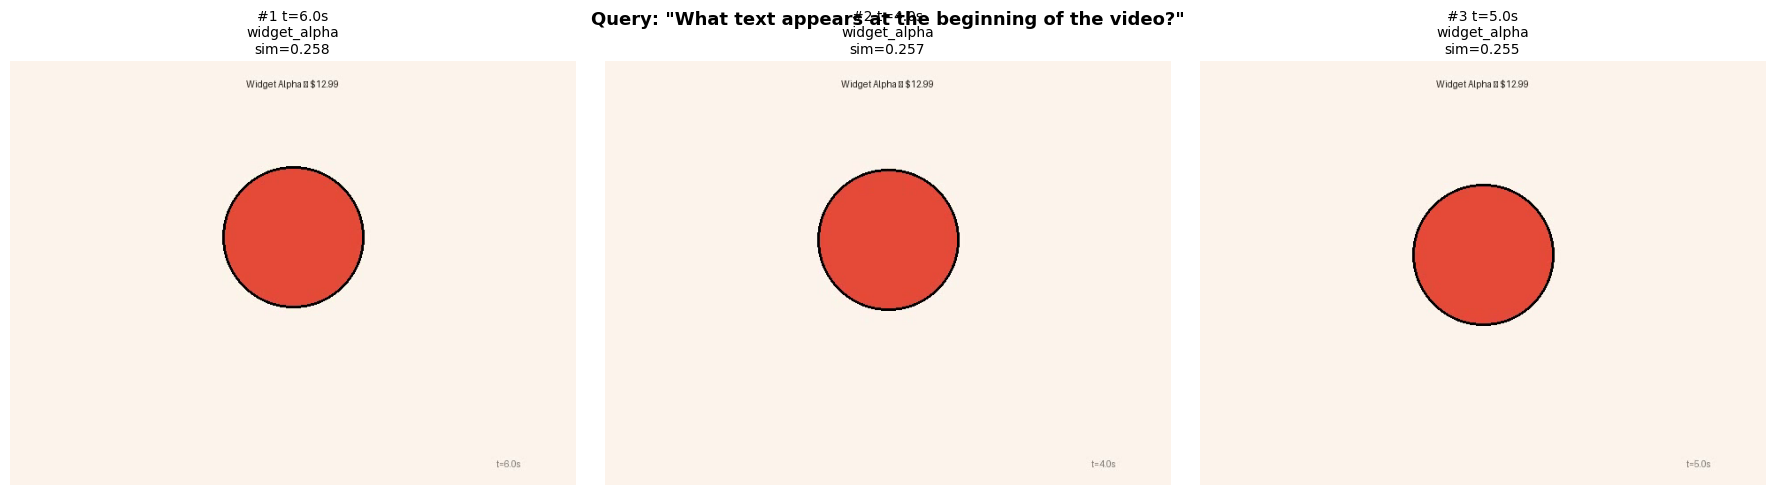


  Answer (provider: Ollama):
The provided frames do not show the beginning of the video. The earliest available frame is at **t=4.0s**, which shows text for "Widget Alpha: red circle, $12.99." 

I cannot see what text appears at the very start of the video (around t=0s) as no frames from that time period were retrieved.

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] quota/rate-limit hit — trying next provider ...
  Answer (provider: Ollama):
I don't have information about a specific video you're referring to. Could you please provide more details, such as:

- The title of the video
- A link to the video
- A description of what the video is about (e.g., a movie, TV show, YouTube video, tutorial, etc.)
- The creator or channel name

Once you provide more context, I'll be happy to help you identify the text that appears at the beginning.



In [11]:
questions = [
    "What is the red product shown in the video and how much does it cost?",
    #"At what point in the video does the green triangle appear?",
    #"What is the most expensive product in this showcase video?",
    #"What shape is the orange product?",
    "What text appears at the beginning of the video?",
]


def preview(text, max_len=800):
    text = text or ""
    return text[:max_len] + ("..." if len(text) > max_len else "")


if not has_llm_provider():
    print("Error: Set GEMINI_API_KEY or OLLAMA_API_KEY before running.")
else:
    for i, q in enumerate(questions, start=1):
        print("\n" + "=" * 80)
        print(f"Q{i}. {q}")
        print("=" * 80)

        # --- WITH VIDEO RAG ---
        print("\n--- WITH VIDEO RAG ---")
        try:
            answer_rag, retrieved, prov = answer_with_video_rag(q)
            show_retrieved_frames(q, retrieved)
            print(f"\n  Answer (provider: {prov}):")
            print(preview(answer_rag))
        except Exception as e:
            print(f"  RAG error: {e}")

        # --- WITHOUT RAG ---
        print("\n--- WITHOUT RAG (LLM knowledge only) ---")
        try:
            answer_direct, prov_direct = generate_answer_without_rag(q)
            print(f"  Answer (provider: {prov_direct}):")
            print(preview(answer_direct))
        except Exception as e:
            print(f"  Direct error: {e}")

        print()

### Checkpoint: Reflection Questions

1. **Temporal grounding:** Did the RAG answers include timestamps? How useful is knowing *when* in the video something appears?
2. **Without-RAG failure:** The LLM has never seen our synthetic video — what kind of responses did it give? Refusal? Hallucination?
3. **Frame sampling:** We sampled 1 frame/second. What would happen with 1 frame every 5 seconds? Every 0.5 seconds?
4. **Comparison with Image RAG:** What extra complexity does the temporal dimension add over static Image RAG?

## 9) Interactive Query (Optional)

Ask your own questions about the product showcase video.

Question: How many products are shown in total, and what are their prices?

WITH VIDEO RAG:
  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 4 frame(s):
           #1 t=14.0s — Tool Gamma (sim=0.246)
           #2 t=11.0s — Tool Gamma (sim=0.243)
           #3 t=13.0s — Tool Gamma (sim=0.243)
           #4 t=12.0s — Tool Gamma (sim=0.241)
  [Step 3] Generating multimodal answer ...
  [Gemini] quota/rate-limit hit — trying next provider ...
  [Step 4] Answer generated (provider: Ollama)


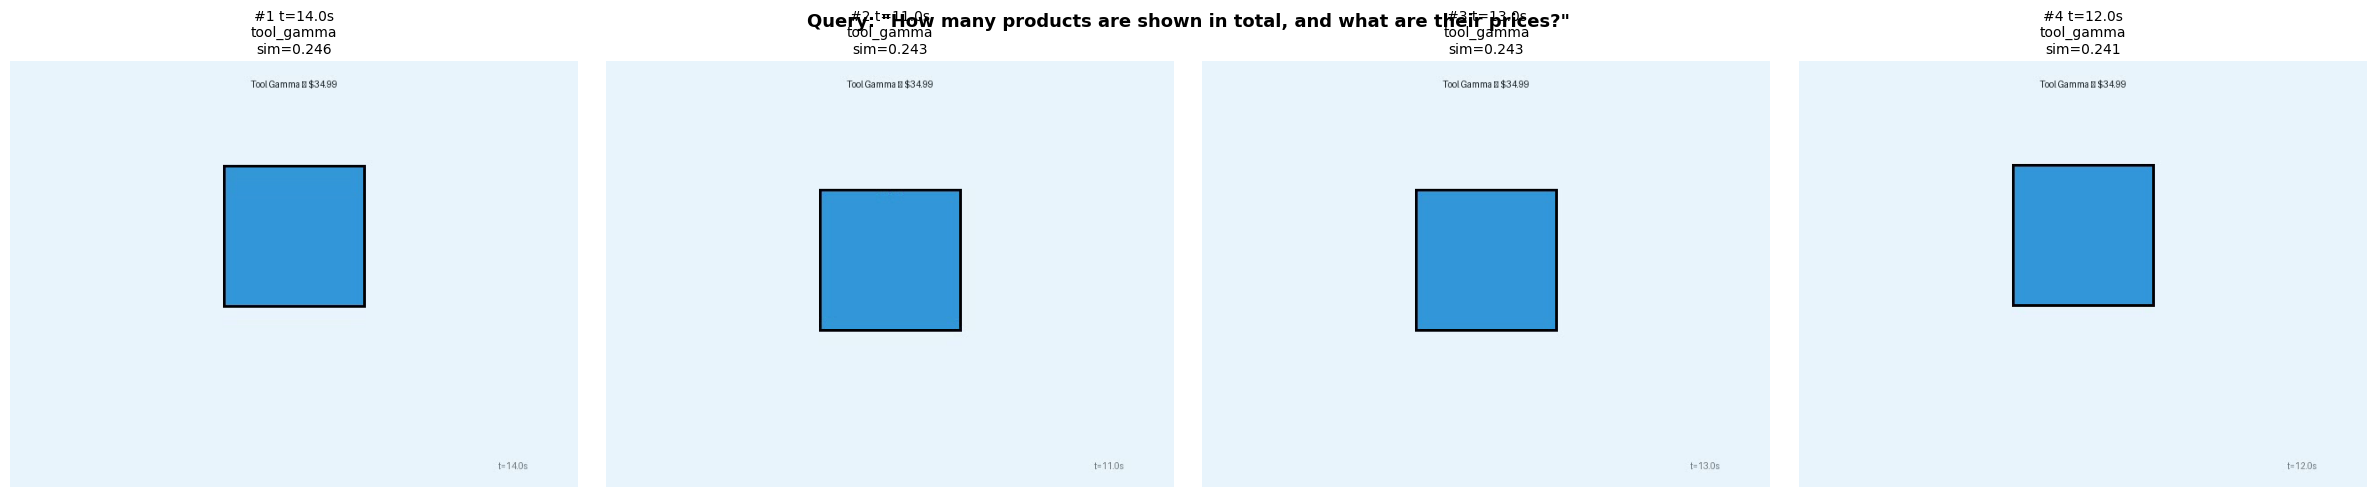


Answer (Ollama):
Based on the provided frames, **one product** is shown in total: **Tool Gamma**, priced at **$34.99**.

This product (described as a "blue square") appears consistently across all four provided timestamps: at **t=11.0s**, **t=12.0s**, **t=13.0s**, and **t=14.0s**. 

*Note: These are the only frames provided, so I cannot determine if additional products appear elsewhere in the full video.*

WITHOUT RAG:
  [Gemini] quota/rate-limit hit — trying next provider ...

Answer (Ollama):
I don't see any image or product list in your message. Could you please share the image or describe the products you're referring to? Once you provide the details, I'll be happy to tell you:

- The total number of products shown
- The price of each product

Please upload the image or paste the product information, and I'll analyze it for you right away!


In [12]:
# Change this to any question about the product showcase video
my_question = "How many products are shown in total, and what are their prices?"

if has_llm_provider():
    print(f"Question: {my_question}\n")

    print("=" * 60)
    print("WITH VIDEO RAG:")
    print("=" * 60)
    try:
        answer, retrieved, provider = answer_with_video_rag(my_question, top_k=4)
        show_retrieved_frames(my_question, retrieved)
        print(f"\nAnswer ({provider}):\n{answer}")
    except Exception as e:
        print(f"Error: {e}")

    print("\n" + "=" * 60)
    print("WITHOUT RAG:")
    print("=" * 60)
    try:
        answer_direct, prov_direct = generate_answer_without_rag(my_question)
        print(f"\nAnswer ({prov_direct}):\n{answer_direct}")
    except Exception as e:
        print(f"Error: {e}")
else:
    print("Set GEMINI_API_KEY or OLLAMA_API_KEY first.")

## 10) Teaching Notes and Exercises

**Key takeaways:**
- **Video RAG = frame extraction + Image RAG + temporal metadata.** The video is decomposed into keyframes that are indexed and retrieved just like static images.
- **Timestamps add a temporal dimension** that Image RAG lacks — answers can reference *when* in the video something occurs.
- **Frame sampling rate** is a key design choice: too sparse and you miss content; too dense and you waste compute and storage.
- The same **CLIP + multimodal LLM** stack from Image RAG works here — the main new component is the frame extraction step.
- **Without-RAG comparison** is especially stark for video: the LLM has never seen the video, so it either refuses or hallucinates.

**Exercises:**
- Download a short YouTube clip (e.g., a product review) and replace the synthetic video. How does CLIP handle real-world video frames?
- Experiment with different frame sampling rates (0.5s, 2s, 5s) and measure the impact on retrieval accuracy.
- Add **scene change detection** instead of fixed-interval sampling — extract frames only when the visual content changes significantly.
- Combine video frames with **audio transcription** (e.g., Whisper) for a multimodal RAG that uses both visual and spoken content.
- Discuss: In what business scenarios is Video RAG most valuable? (e.g., surveillance review, training video search, meeting recording Q&A, sports analytics)